In [ ]:
import pandas as pd

In [3]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt

In [7]:
import seaborn as sns

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score

In [11]:
from sklearn.preprocessing import StandardScaler

In [13]:
from sklearn import linear_model

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [17]:
import warnings
warnings.filterwarnings('ignore')

**Train Data**

In [20]:
activity_labels = pd.read_csv("activity_labels.txt", sep=" ", header=None, names=["ActivityID", "ActivityName"])
activity_labels

,ActivityID,ActivityName
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


In [22]:
features = pd.read_csv("features.txt", delim_whitespace=True, header=None, usecols=[1]) 
features

,1
0,tBodyAcc-mean()-X
1,tBodyAcc-mean()-Y
2,tBodyAcc-mean()-Z
3,tBodyAcc-std()-X
4,tBodyAcc-std()-Y
...,...
556,"angle(tBodyGyroMean,gravityMean)"
557,"angle(tBodyGyroJerkMean,gravityMean)"
558,"angle(X,gravityMean)"
559,"angle(Y,gravityMean)"


In [24]:
train_folder = r"C:\Users\tanug\Downloads\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset\train"

In [26]:
import os

train_folder =r"C:\Users\tanug\Downloads\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset\train"
file_path = os.path.join(train_folder, r"C:\Users\tanug\Downloads\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset\train\X_train.txt")  
x_train = pd.read_csv(file_path, delim_whitespace=True, header=None)

In [28]:
x_train.columns = features[1].values 

In [30]:
x_train

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7347,0.299665,-0.057193,-0.181233,-0.195387,0.039905,0.077078,-0.282301,0.043616,0.060410,0.210795,...,-0.070157,-0.588433,-0.880324,-0.190437,0.829718,0.206972,-0.425619,-0.791883,0.238604,0.049819
7348,0.273853,-0.007749,-0.147468,-0.235309,0.004816,0.059280,-0.322552,-0.029456,0.080585,0.117440,...,0.165259,-0.390738,-0.680744,0.064907,0.875679,-0.879033,0.400219,-0.771840,0.252676,0.050053
7349,0.273387,-0.017011,-0.045022,-0.218218,-0.103822,0.274533,-0.304515,-0.098913,0.332584,0.043999,...,0.195034,0.025145,-0.304029,0.052806,-0.266724,0.864404,0.701169,-0.779133,0.249145,0.040811
7350,0.289654,-0.018843,-0.158281,-0.219139,-0.111412,0.268893,-0.310487,-0.068200,0.319473,0.101702,...,0.013865,0.063907,-0.344314,-0.101360,0.700740,0.936674,-0.589479,-0.785181,0.246432,0.025339


In [32]:
y_train_path = os.path.join(train_folder,r"C:\Users\tanug\Downloads\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset\train\y_train.txt" )
subject_train_path = os.path.join(train_folder,r"C:\Users\tanug\Downloads\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset\train\subject_train.txt")

y_train = pd.read_csv(y_train_path, sep="\s+", header=None, names=["ActivityID"])
subject_train = pd.read_csv(subject_train_path, sep="\s+", header=None, names=["Subject"])

In [34]:
y_train

,ActivityID
0,5
1,5
2,5
3,5
4,5
...,...
7347,2
7348,2
7349,2
7350,2


In [36]:
subject_train

,Subject
0,1
1,1
2,1
3,1
4,1
...,...
7347,30
7348,30
7349,30
7350,30


In [38]:
y_train = y_train.merge(activity_labels, on="ActivityID", how="left")
y_train

,ActivityID,ActivityName
0,5,STANDING
1,5,STANDING
2,5,STANDING
3,5,STANDING
4,5,STANDING
...,...,...
7347,2,WALKING_UPSTAIRS
7348,2,WALKING_UPSTAIRS
7349,2,WALKING_UPSTAIRS
7350,2,WALKING_UPSTAIRS


In [40]:
train_data = pd.concat([subject_train, y_train["ActivityName"], x_train], axis=1)
train_data

,Subject,ActivityName,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,1,STANDING,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,1,STANDING,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,1,STANDING,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,1,STANDING,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,1,STANDING,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7347,30,WALKING_UPSTAIRS,0.299665,-0.057193,-0.181233,-0.195387,0.039905,0.077078,-0.282301,0.043616,...,-0.070157,-0.588433,-0.880324,-0.190437,0.829718,0.206972,-0.425619,-0.791883,0.238604,0.049819
7348,30,WALKING_UPSTAIRS,0.273853,-0.007749,-0.147468,-0.235309,0.004816,0.059280,-0.322552,-0.029456,...,0.165259,-0.390738,-0.680744,0.064907,0.875679,-0.879033,0.400219,-0.771840,0.252676,0.050053
7349,30,WALKING_UPSTAIRS,0.273387,-0.017011,-0.045022,-0.218218,-0.103822,0.274533,-0.304515,-0.098913,...,0.195034,0.025145,-0.304029,0.052806,-0.266724,0.864404,0.701169,-0.779133,0.249145,0.040811
7350,30,WALKING_UPSTAIRS,0.289654,-0.018843,-0.158281,-0.219139,-0.111412,0.268893,-0.310487,-0.068200,...,0.013865,0.063907,-0.344314,-0.101360,0.700740,0.936674,-0.589479,-0.785181,0.246432,0.025339


In [42]:
train_data.to_csv("final_train_data.csv", index=False)

**Test Data**

In [44]:
test_folder = r"C:\Users\tanug\Downloads\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset\test"

In [47]:
test_folder = r"C:\Users\batha\Downloads\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset\test\X_test.txt"
file_path = os.path.join(train_folder,r"C:\Users\tanug\Downloads\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset\test\X_test.txt")  

x_test = pd.read_csv(file_path, delim_whitespace=True, header=None)

In [49]:
x_test.columns = features[1].values 
x_test

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,0.071645,-0.330370,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.401189,-0.121845,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,0.062891,-0.190422,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,0.116695,-0.344418,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.121711,-0.534685,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2942,0.310155,-0.053391,-0.099109,-0.287866,-0.140589,-0.215088,-0.356083,-0.148775,-0.232057,0.185361,...,0.074472,-0.376278,-0.750809,-0.337422,0.346295,0.884904,-0.698885,-0.651732,0.274627,0.184784
2943,0.363385,-0.039214,-0.105915,-0.305388,0.028148,-0.196373,-0.373540,-0.030036,-0.270237,0.185361,...,0.101859,-0.320418,-0.700274,-0.736701,-0.372889,-0.657421,0.322549,-0.655181,0.273578,0.182412
2944,0.349966,0.030077,-0.115788,-0.329638,-0.042143,-0.250181,-0.388017,-0.133257,-0.347029,0.007471,...,-0.066249,-0.118854,-0.467179,-0.181560,0.088574,0.696663,0.363139,-0.655357,0.274479,0.181184
2945,0.237594,0.018467,-0.096499,-0.323114,-0.229775,-0.207574,-0.392380,-0.279610,-0.289477,0.007471,...,-0.046467,-0.205445,-0.617737,0.444558,-0.819188,0.929294,-0.008398,-0.659719,0.264782,0.187563


In [51]:
test_folder = r"C:\Users\tanug\Downloads\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset\test"


y_test_path = os.path.join(test_folder,r"C:\Users\tanug\Downloads\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset\test\y_test.txt")
subject_test_path = os.path.join(test_folder, r"C:\Users\tanug\Downloads\human+activity+recognition+using+smartphones\UCI HAR Dataset\UCI HAR Dataset\test\subject_test.txt")


y_test = pd.read_csv(y_test_path, delim_whitespace=True, header=None, names=["ActivityID"])
subject_test = pd.read_csv(subject_test_path, delim_whitespace=True, header=None, names=["Subject"])

In [53]:
y_test.head()

,ActivityID
0,5
1,5
2,5
3,5
4,5


In [55]:
subject_test.head()

,Subject
0,2
1,2
2,2
3,2
4,2


In [57]:
y_test = y_test.merge(activity_labels, on="ActivityID", how="left")
y_test.head()

,ActivityID,ActivityName
0,5,STANDING
1,5,STANDING
2,5,STANDING
3,5,STANDING
4,5,STANDING


In [59]:
test_data = pd.concat([subject_test, y_test["ActivityName"], x_test], axis=1)
test_data.head()

,Subject,ActivityName,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,2,STANDING,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,...,0.071645,-0.330370,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978
1,2,STANDING,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,...,-0.401189,-0.121845,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898
2,2,STANDING,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,...,0.062891,-0.190422,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346
3,2,STANDING,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,...,0.116695,-0.344418,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108
4,2,STANDING,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,...,-0.121711,-0.534685,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857


In [61]:
test_data.to_csv("final_test_data.csv", index=False)

In [62]:
train_data.shape

(7352, 563)

In [63]:
test_data.shape

(2947, 563)

In [67]:
train_data.max()

Subject                                               30
ActivityName                            WALKING_UPSTAIRS
tBodyAcc-mean()-X                                    1.0
tBodyAcc-mean()-Y                                    1.0
tBodyAcc-mean()-Z                                    1.0
                                              ...       
angle(tBodyGyroMean,gravityMean)                0.998702
angle(tBodyGyroJerkMean,gravityMean)            0.996078
angle(X,gravityMean)                                 1.0
angle(Y,gravityMean)                            0.478157
angle(Z,gravityMean)                                 1.0
Length: 563, dtype: object

**# Merge train and test data**

In [70]:
full_data = pd.concat([train_data, test_data], axis=0).reset_index(drop=True)

In [72]:
full_data

,Subject,ActivityName,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,1,STANDING,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,1,STANDING,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,1,STANDING,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,1,STANDING,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,1,STANDING,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10294,24,WALKING_UPSTAIRS,0.310155,-0.053391,-0.099109,-0.287866,-0.140589,-0.215088,-0.356083,-0.148775,...,0.074472,-0.376278,-0.750809,-0.337422,0.346295,0.884904,-0.698885,-0.651732,0.274627,0.184784
10295,24,WALKING_UPSTAIRS,0.363385,-0.039214,-0.105915,-0.305388,0.028148,-0.196373,-0.373540,-0.030036,...,0.101859,-0.320418,-0.700274,-0.736701,-0.372889,-0.657421,0.322549,-0.655181,0.273578,0.182412
10296,24,WALKING_UPSTAIRS,0.349966,0.030077,-0.115788,-0.329638,-0.042143,-0.250181,-0.388017,-0.133257,...,-0.066249,-0.118854,-0.467179,-0.181560,0.088574,0.696663,0.363139,-0.655357,0.274479,0.181184
10297,24,WALKING_UPSTAIRS,0.237594,0.018467,-0.096499,-0.323114,-0.229775,-0.207574,-0.392380,-0.279610,...,-0.046467,-0.205445,-0.617737,0.444558,-0.819188,0.929294,-0.008398,-0.659719,0.264782,0.187563


In [74]:
full_data.shape

(10299, 563)

**# Data Preprocessing**

In [77]:
missing_values = full_data.isnull().sum()
print("Missing values in each column:\n", missing_values[missing_values > 0])

Missing values in each column:
 Series([], dtype: int64)


In [79]:
from sklearn.model_selection import train_test_split

In [81]:
X = full_data.drop(columns=["Subject", "ActivityName"])
y = full_data["ActivityName"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

**# Standardization**

In [84]:
scaler = StandardScaler()

In [86]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**# Visualization 1: Activity Distribution**

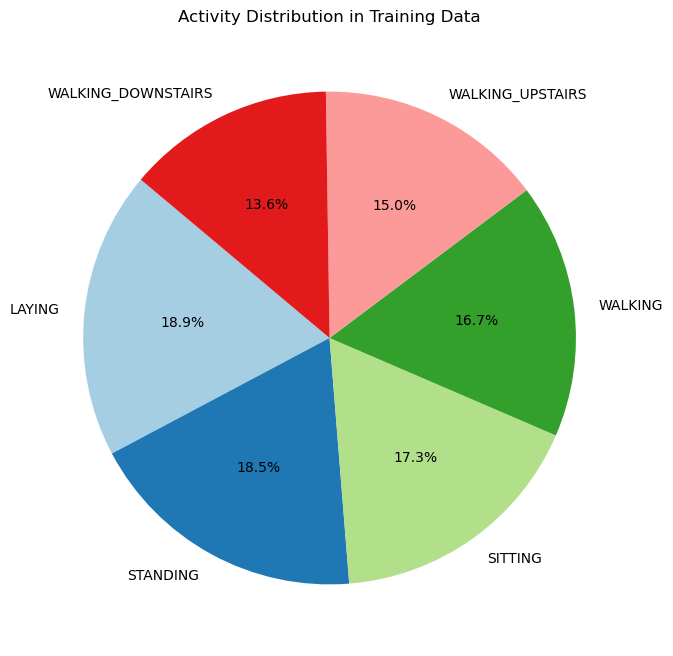

In [89]:
activity_counts = pd.Series(y_train).value_counts()

plt.figure(figsize=(8, 8))
plt.pie(activity_counts, labels=activity_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title("Activity Distribution in Training Data")
plt.show()

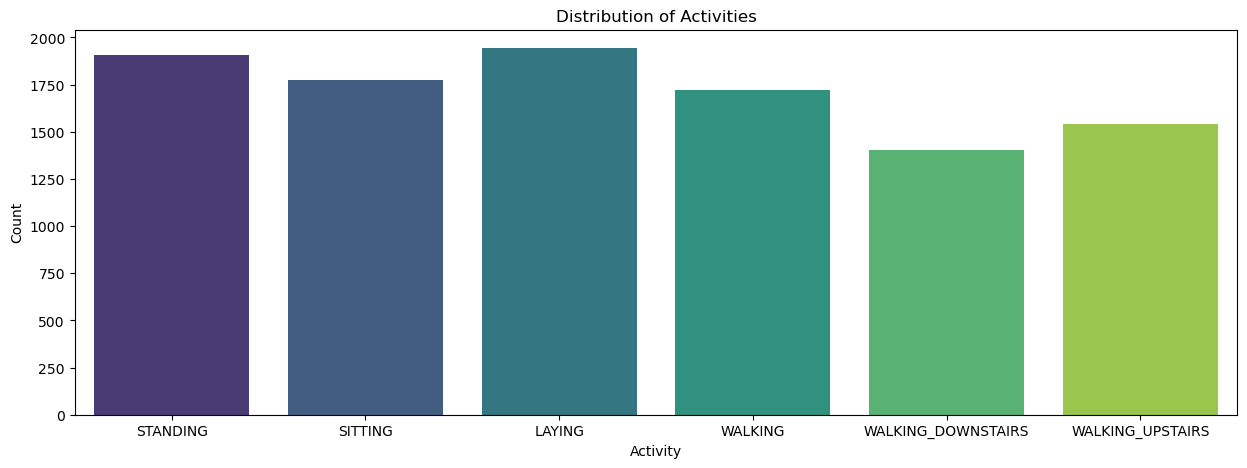

In [91]:
plt.figure(figsize=(15, 5))
sns.countplot(x=full_data["ActivityName"], palette="viridis") 
plt.title("Distribution of Activities")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.show()

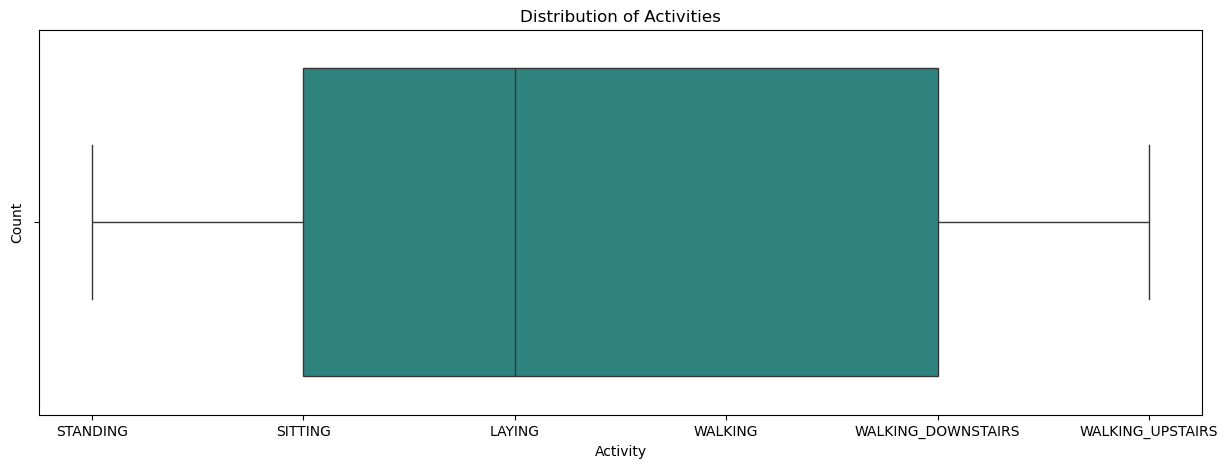

In [93]:
plt.figure(figsize=(15, 5))
sns.boxplot(x=full_data["ActivityName"], palette="viridis") 
plt.title("Distribution of Activities")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.show()

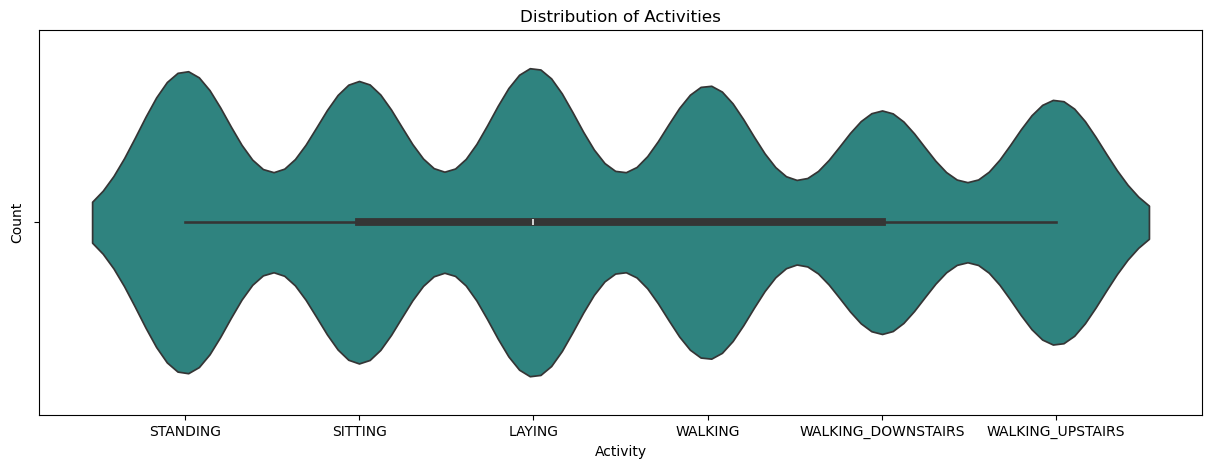

In [95]:
plt.figure(figsize=(15, 5))
sns.violinplot(x=full_data["ActivityName"], palette="viridis") 
plt.title("Distribution of Activities")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.show()

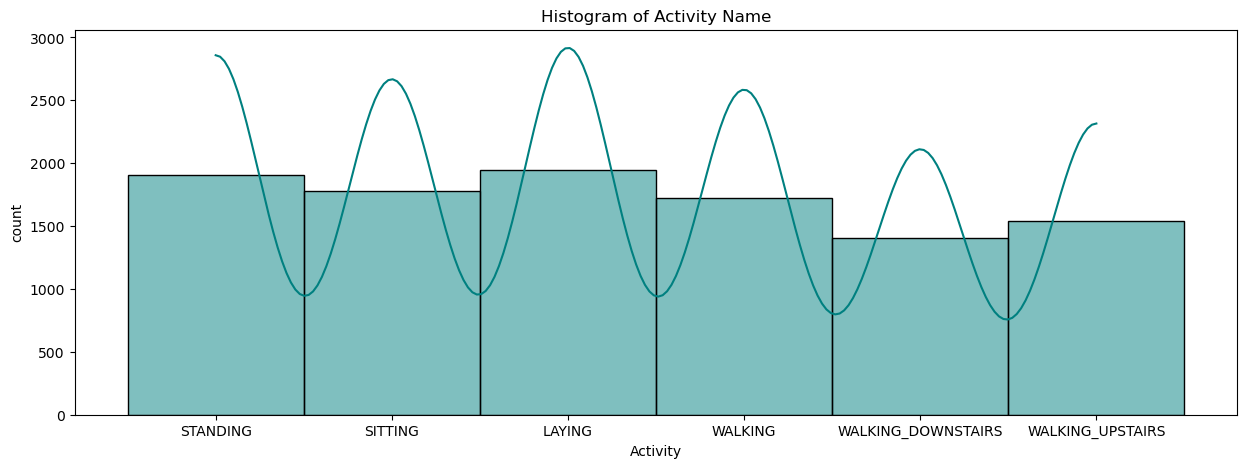

In [168]:
plt.figure(figsize=(15, 5))
sns.histplot(full_data["ActivityName"], bins=30, kde=True, color='teal')
plt.title("Histogram of Activity Name")
plt.xlabel("Activity")
plt.ylabel("count")
plt.show()


In [104]:
from sklearn.linear_model import LogisticRegression

In [106]:
lr=linear_model.LogisticRegression()

In [108]:
lr= LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
feature_importances = pd.Series(abs(lr.coef_).mean(axis=0), index=X.columns).sort_values(ascending=False)[:10]

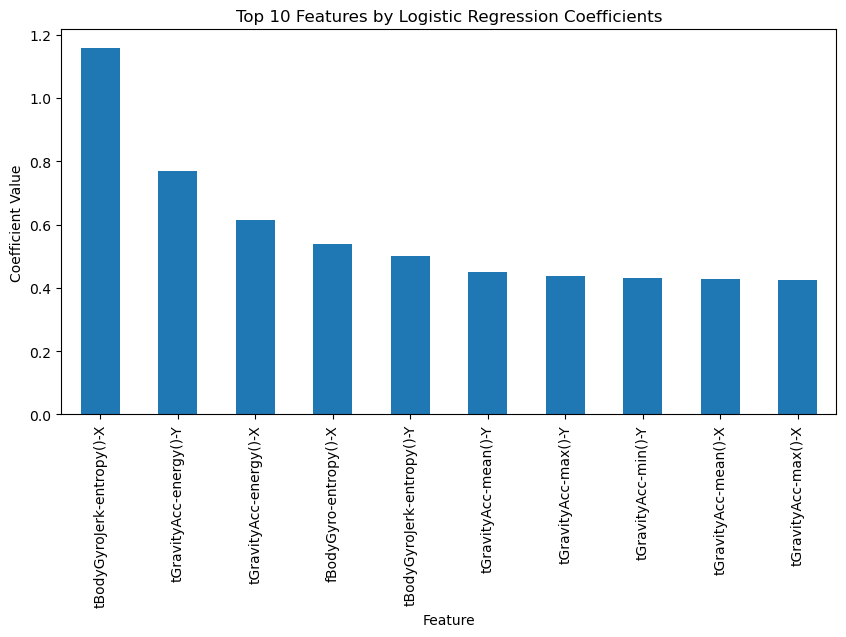

In [109]:
feature_importances.plot(kind='bar', figsize=(10, 5), title="Top 10 Features by Logistic Regression Coefficients")
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.show()

**# Model Training - Logistic Regression**

In [113]:
from sklearn.linear_model import LogisticRegression

In [115]:
log_reg = LogisticRegression(multi_class="multinomial")
log_reg.fit(X_train, y_train)

LogisticRegression(multi_class='multinomial')

In [117]:
log_pred = log_reg.predict(X_test)

**# Model Training - Naive Bayes**

In [120]:
from sklearn.naive_bayes import GaussianNB

In [122]:
nb_model = GaussianNB()

In [124]:
nb_model.fit(X_train, y_train)

GaussianNB()

In [126]:
nb_pred = nb_model.predict(X_test)

**# Model Evaluation**

In [129]:
models = {"Logistic Regression": log_pred, "Naive Bayes": nb_pred}
for name, pred in models.items():
    print(f"\n{name} Model Evaluation:")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Classification Report:\n", classification_report(y_test, pred))
    


Logistic Regression Model Evaluation:
Accuracy: 0.9802588996763754
Classification Report:
                     precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       583
           SITTING       0.95      0.95      0.95       533
          STANDING       0.96      0.95      0.96       572
           WALKING       0.99      1.00      1.00       517
WALKING_DOWNSTAIRS       0.99      0.99      0.99       422
  WALKING_UPSTAIRS       0.99      0.99      0.99       463

          accuracy                           0.98      3090
         macro avg       0.98      0.98      0.98      3090
      weighted avg       0.98      0.98      0.98      3090


Naive Bayes Model Evaluation:
Accuracy: 0.7459546925566343
Classification Report:
                     precision    recall  f1-score   support

            LAYING       0.99      0.95      0.97       583
           SITTING       0.53      0.92      0.67       533
          STANDING       0.83      0.26 

**# Confusion Matrix**

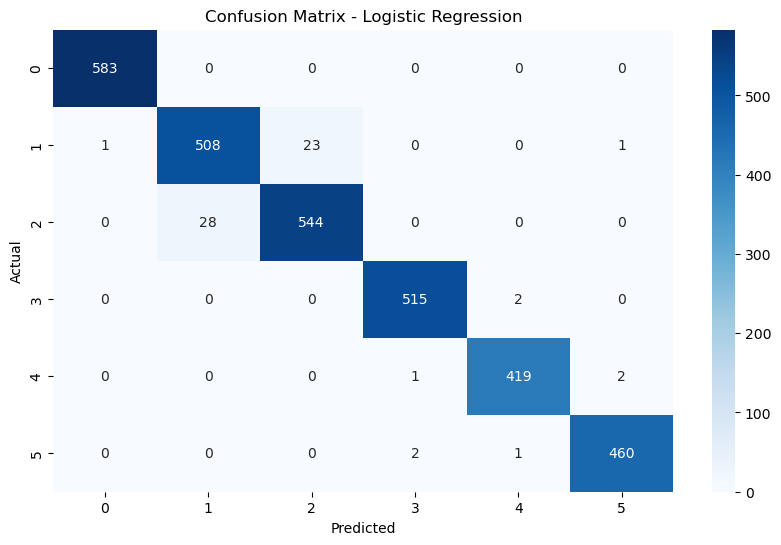

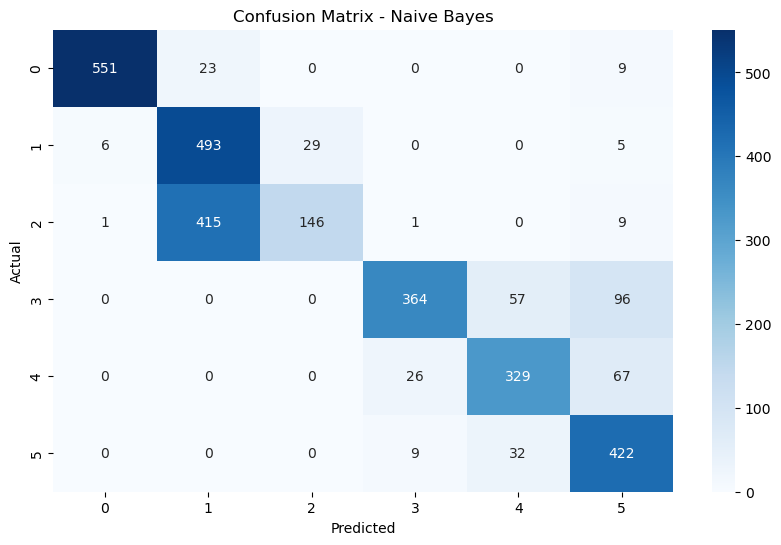

In [132]:
for name, pred in models.items():
    plt.figure(figsize=(10, 6))
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [134]:
model_accuracies={"Logistic Regression":98.025, "Naive Bayes":74.595}

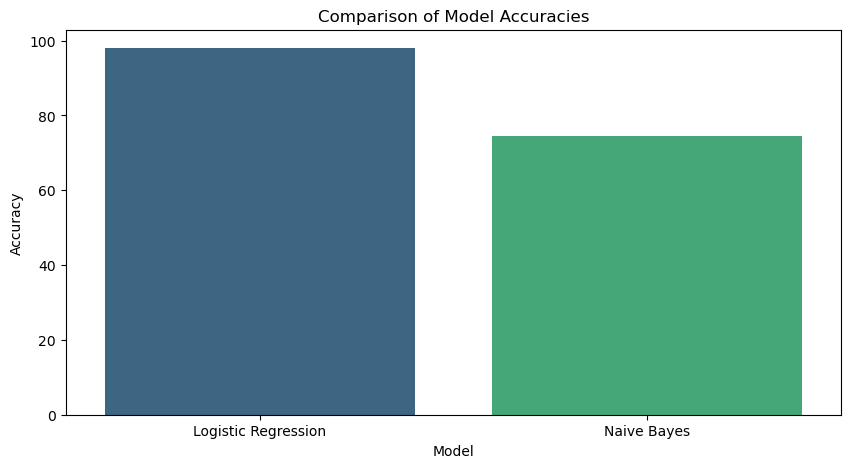

In [136]:
plt.figure(figsize=(10, 5))
sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()), palette="viridis")
plt.title("Comparison of Model Accuracies")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

In [148]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

In [150]:
X = full_data.drop(columns=["Subject", "ActivityName"])
y = full_data["ActivityName"]              


label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

model = RandomForestClassifier(n_estimators=100, random_state=42)

cv_scores = cross_val_score(model, X, y_encoded, cv=5, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print("Average accuracy:", np.mean(cv_scores))

Cross-validation scores: [0.93980583 0.92378641 0.94126214 0.93640777 0.93734823]
Average accuracy: 0.9357220726434268


In [156]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []


for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

print("K-Fold Accuracy Scores:", scores)
print("Average Accuracy:", np.mean(scores))

K-Fold Accuracy Scores: [0.9796116504854369, 0.9791262135922331, 0.9776699029126213, 0.9815533980582525, 0.9757163671685284]
Average Accuracy: 0.9787355064434144


In [158]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for train_idx, test_idx in skf.split(X, y_encoded):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

print("Stratified K-Fold scores:", scores)
print("Average Accuracy:", np.mean(scores))


Stratified K-Fold scores: [0.9781553398058253, 0.9776699029126213, 0.9766990291262136, 0.9752427184466019, 0.9834871296745993]
Average Accuracy: 0.9782508239931722
